<a href="https://colab.research.google.com/github/SalvatoreSisay/Challenge-Telecome-X/blob/main/Challenge_TelecomX_LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X — Análisis de Evasión de Clientes 🕵️

**Objetivo**: Analizar un suceso que enfrenta la empresa sobre la evasión de clientes parte del proyecto **"Churn de Clientes"** a partir de datos demográficos, de servicios y de facturación, identificando patrones que puedan apoyar estrategias de retención.

Fuente de datos: archivo JSON obtenido en el repositorio oficial del challenge (que son datos en crudo con formato JSON).

#📌 Extracción

✅ Cargar los datos directamente desde la API utilizando Python y convertir los datos en un DataFrame de Pandas.

In [2]:
import pandas as pd
url = '/content/TelecomX_Data.json'
#El url se puede remplazar usando el link directo del repositorio o en mi caso
#para uso mas practico cargar la ruta del archivo dentro del notebook.
#link del url del repo "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

✅ Despues de haber extraído los datos, es fundamental comprender la estructura del dataset asi que en esta etapa identificaremos qué variables son más relevantes para el análisis de evasión de clientes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Normalizacion del Json

In [5]:
df_normalized = pd.json_normalize(df.to_dict(orient="records"))
df_normalized.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

A partir del diccionario de datos dado en el repositorio (adjunto link de la url "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_diccionario.md"), se seleccionaron las variables más relevantes para el análisis de evasión de clientes, teniendo la prioridad en la información sobre contratos, antigüedad y cargos.

## Comprobación de incoherencias en los datos.
Limpieza, tratamiento y verificación de incoherencias.

In [8]:
dup_customer = df_normalized['customerID'].duplicated().sum()
#Verificacion basica de duplicados
dup_customer

np.int64(0)

In [9]:
df_normalized['Churn'] = df_normalized['Churn'].astype(str).str.strip()
#Normalizo
df_normalized = df_normalized[df_normalized['Churn'].isin(['Yes', 'No'])].copy()
#Filtrar valores validos de "Yes/No"
df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [10]:

# Ingresa como texto y lo convertimos a numérico para análisis cuantitativo
df_normalized['account.Charges.Total'] = pd.to_numeric(df_normalized['account.Charges.Total'], errors='coerce')

# Asumimos total gastado = 0; sin historial de cobro acumulado
mask_tenure0 = df_normalized['customer.tenure'] == 0
df_normalized.loc[mask_tenure0, 'account.Charges.Total'] = 0

# Revisión de nulos remanentes
df_normalized['account.Charges.Total'].isna().sum()

np.int64(0)

In [11]:
# Verificacion de los tipos consistentes y sin nulos en variables clave
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

Se verificaron los datos y no se presentaron valores nulos y hay inexistencia de datos duplicados y se corrigieron errores de formato en variables numéricas y se validaron los valores de la variable Churn, asegurando que los datos estén listos para el análisis exploratorio.

### Columna de cuentas diarias (Opcional)

Se utilizara la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [12]:
df_normalized['Cuentas_Diarias'] = df_normalized['account.Charges.Monthly'] / 30

df_normalized[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### Estandarización y transformación de datos (opcional)

Se hara transformacion de los datos para que sean mas comprensibles, consistentes y adecuados para el analisis ademas de traducir o renombrar columnas y datos

In [13]:
df_normalized['Churn_bin'] = df_normalized['Churn'].map({'No': 0, 'Yes': 1})
df_normalized['PaperlessBilling_bin'] = df_normalized['account.PaperlessBilling'].map({'No': 0, 'Yes': 1})

df_normalized[['Churn','Churn_bin','account.PaperlessBilling','PaperlessBilling_bin']].head()

,Churn,Churn_bin,account.PaperlessBilling,PaperlessBilling_bin
0,No,0,Yes,1
1,No,0,No,0
2,Yes,1,Yes,1
3,Yes,1,Yes,1
4,Yes,1,Yes,1


#📊 Carga y análisis

✅ Ya con los datos tratados ahora realizaremos el analisis exploratorio de los datos, empezando con lo basico para tener un panorama de lo que nos vamos a encontrar lo cual seria un analisis descriptivo calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [15]:
df_normalized[['customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


## Distribución de evasión

In [16]:
churn_pct = df_normalized['Churn'].value_counts(normalize=True) * 100
churn_pct

,proportion
Churn,
No,73.463013
Yes,26.536987


Se logra apreciar la proporción de clientes que permanecen contra los que abandonan.

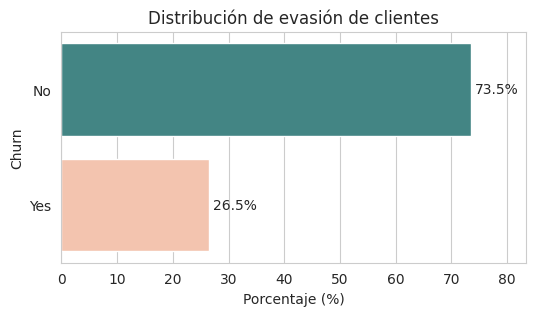

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("whitegrid")

# Convert the churn_pct Series to a DataFrame
churn_df = churn_pct.reset_index()
churn_df.columns = ['Churn', 'Porcentaje']

plt.figure(figsize=(6,3))
ax = sns.barplot(
    data=churn_df,
    y='Churn',
    x='Porcentaje',
    orient='h',
    hue='Churn',
    palette={
        'No': '#38908F',
        'Yes': '#FFBFA3'
    },
    legend=False
)

plt.title('Distribución de evasión de clientes')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Churn')

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlim(0, churn_df['Porcentaje'].max() + 10)
plt.show()

Se puede observar que aproximadamente el 73.5% de los clientes no han abandonado el servicio, mientras que un 26.5% sí lo han hecho. Esto nos da una idea clara de la proporción de clientes que retiene la empresa y los que se van.

## Recuento de evasión por variables categóricas

exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras, este análisis puede revelar patrones interesantes.

#### **Churn según tipo de contrato**

In [25]:
churn_by_contract = (
    df_normalized
    .groupby('account.Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_contract

,account.Contract,Churn,percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.730482
3,One year,Yes,11.269518
4,Two year,No,97.168142
5,Two year,Yes,2.831858


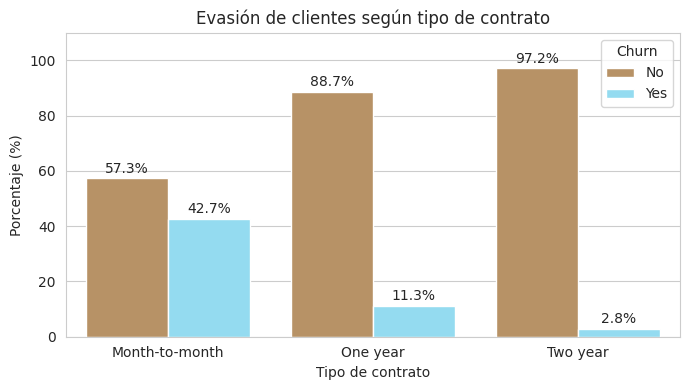

In [43]:
plt.figure(figsize=(7,4))

# Define the order for the contract types
order_contract = ['Month-to-month', 'One year', 'Two year']

ax = sns.barplot(
    data=churn_by_contract,
    x='account.Contract',
    y='percentage',
    hue='Churn',
    order=order_contract,
    palette={
        'No': '#C59358',
        'Yes': '#85E3FF'
    }
)

plt.title('Evasión de clientes según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje (%)')

# etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.ylim(0, 110)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

Este gráfico nos revela información clave:

Contratos mes a mes (Month-to-month): Tienen la tasa de evasión más alta, con aproximadamente el 42.7% de los clientes abandonando el servicio.
Contratos de un año (One year): Muestran una tasa de evasión considerablemente menor, alrededor del 11.3%.
Contratos de dos años (Two year): Presentan la tasa de evasión más baja, con solo un 2.8%.

Esto sugiere que los contratos a largo plazo, especialmente los de dos años, son más efectivos para retener a los clientes.

#### **Churn según género**

In [28]:
churn_by_gender = (
    df_normalized
    .groupby('customer.gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_gender

,customer.gender,Churn,percentage
0,Female,No,73.079128
1,Female,Yes,26.920872
2,Male,No,73.839662
3,Male,Yes,26.160338


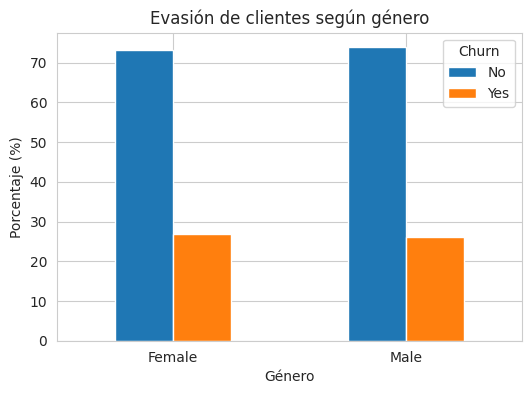

In [29]:

pivot_gender = churn_by_gender.pivot(index='customer.gender', columns='Churn', values='percentage')
pivot_gender.plot(kind='bar', figsize=(6,4), rot=0)
plt.title('Evasión de clientes según género')
plt.xlabel('Género')
plt.ylabel('Porcentaje (%)')
plt.show()

 #### **Churn según método de pago**

In [30]:
churn_by_payment = (
    df_normalized
    .groupby('account.PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_payment


,account.PaymentMethod,Churn,percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


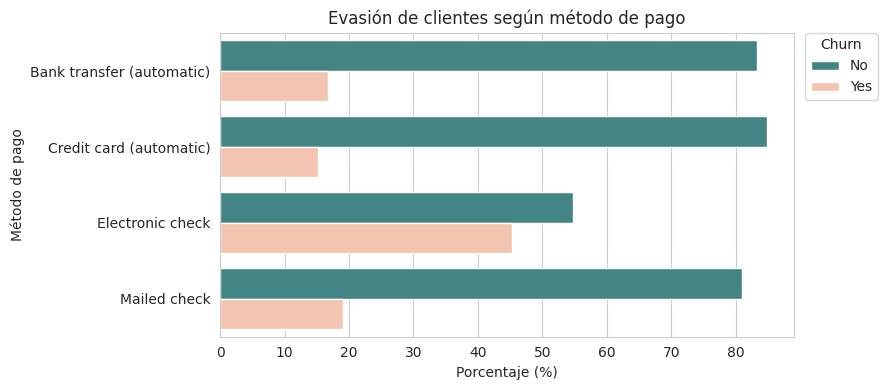

In [44]:
plt.figure(figsize=(9,4))

ax = sns.barplot(
    data=churn_by_payment,
    y='account.PaymentMethod',
    x='percentage',
    hue='Churn',
    palette={'No': '#38908F',
            'Yes': '#FFBFA3'}
)

plt.title('Evasión de clientes según método de pago')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Método de pago')

plt.legend(title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

 En general, el tipo de contrato y el método de pago tienden a mostrar mayores diferencias en churn.

## Conteo de evasión por variables numéricas

Se comprobaran las distribuciones de variables numéricas como por ejemplo antiguedad, cargos mensuales y total de gastos entre clientes que cancelaron y los que no.

Para las variables numéricas se utilizaran boxplots, el cual permite comparar de forma clara la distribución, mediana y presencia de valores atípicos entre clientes que evaden y los que no.

#### Antigüedad vs churn

In [33]:
df_normalized.groupby('Churn')['customer.tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


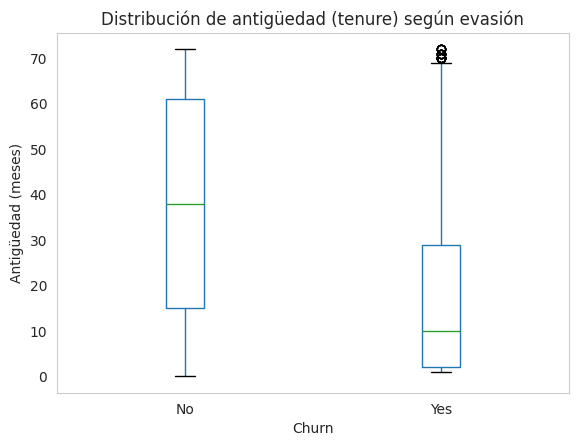

In [34]:
df_normalized.boxplot(column='customer.tenure', by='Churn', grid=False)
plt.title('Distribución de antigüedad (tenure) según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (meses)')
plt.show()

Este gráfico resalta una relación clara: los clientes con menor antigüedad son mucho más propensos a la evasión. Esto es un hallazgo crucial para estrategias de retención, ya que indica que se deben enfocar esfuerzos en los clientes nuevos para evitar que se vayan prematuramente.

#### Cargos mensuales vs churn

In [35]:
df_normalized.groupby('Churn')['account.Charges.Monthly'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


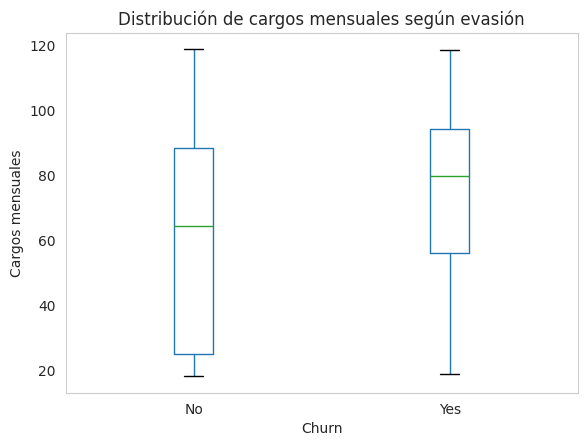

In [36]:
df_normalized.boxplot(column='account.Charges.Monthly', by='Churn', grid=False)
plt.title('Distribución de cargos mensuales según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargos mensuales')
plt.show()

el gráfico sugiere que los clientes con cargos mensuales más altos tienen una mayor tendencia a la evasión. Esto podría deberse a que perciben un menor valor por el costo, o que los altos cargos son un factor directo en su decisión de buscar otras opciones.

#### Total gastado vs churn

In [37]:
df_normalized.groupby('Churn')['account.Charges.Total'].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


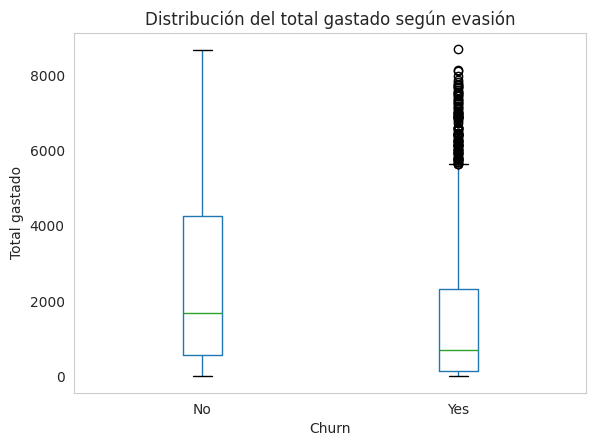

In [38]:
df_normalized.boxplot(column='account.Charges.Total', by='Churn', grid=False)
plt.title('Distribución del total gastado según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

este gráfico complementa lo visto con la antigüedad y los cargos mensuales: **los clientes que han gastado una cantidad total menor son más propensos a la evasión.** Esto podría deberse a que no han estado el tiempo suficiente como para acumular gastos altos, o que la percepción del valor del servicio no justifica el gasto total realizado.

## Análisis de correlación entre variables (Extra - opcional)

Como un paso adicional, exploraremos la correlación entre diferentes variables. Esto puede ayudar a identificar qué factores tienen mayor relación con la evasión de clientes, como:

* La relación entre la cuenta diaria y la evasión.
* Cómo la cantidad de servicios contratados afecta la probabilidad de churn.

In [39]:
corr_vars = df_normalized[['Churn_bin','customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].copy()
corr_matrix = corr_vars.corr(numeric_only=True)
corr_matrix

,Churn_bin,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
Churn_bin,1.000000,-0.352229,0.193356,-0.198324,0.193356
customer.tenure,-0.352229,1.000000,0.247900,0.826178,0.247900
account.Charges.Monthly,0.193356,0.247900,1.000000,0.651174,1.000000
account.Charges.Total,-0.198324,0.826178,0.651174,1.000000,0.651174
Cuentas_Diarias,0.193356,0.247900,1.000000,0.651174,1.000000


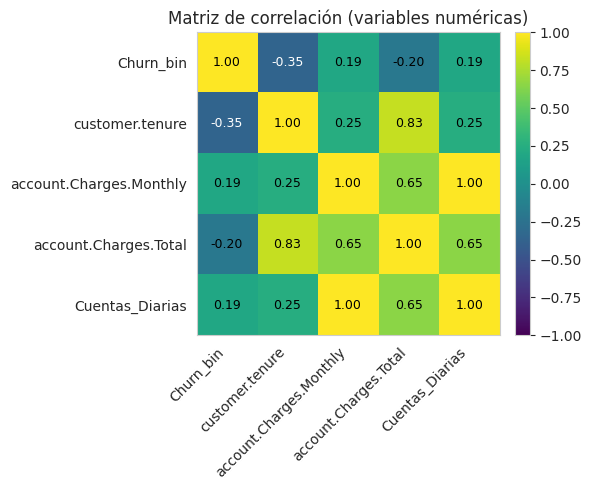

In [45]:
fig, ax = plt.subplots(figsize=(6,5))

ax.grid(False)

im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap='viridis')

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

# Anotaciones con lógica clara y legible
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix.iloc[i, j]

        # Blanco solo para valores negativos fuertes (fondos oscuros)
        text_color = 'white' if value < -0.3 else 'black'

        ax.text(
            j, i,
            f"{value:.2f}",
            ha='center',
            va='center',
            fontsize=9,
            color=text_color
        )

plt.title('Matriz de correlación (variables numéricas)')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

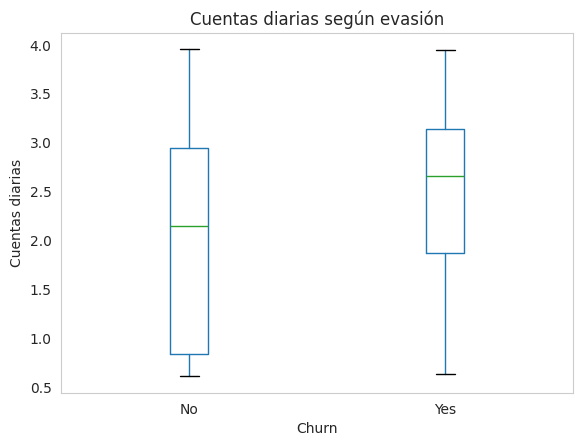

In [41]:
df_normalized.boxplot(
    column='Cuentas_Diarias',
    by='Churn',
    grid=False
)
plt.title('Cuentas diarias según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cuentas diarias')
plt.show()

la antigüedad (tenure) y el total gastado (Charges Total) tienen una correlación negativa más notable con el churn, lo que subraya su importancia en la retención de clientes. Esto refuerza las conclusiones obtenidas con los account.Charges.Monthly, ya que 'Cuentas_Diarias' es una métrica derivada directamente de los cargos mensuales. Ambos gráficos indican que los clientes con gastos diarios/mensuales más altos tienden a tener una mayor tasa de evasión. Esto podría deberse a una percepción de bajo valor por el precio, o a que el costo es un factor determinante en su decisión de buscar alternativas más económicas.

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en Telecom X

**Objetivo del Análisis**: El presente estudio se llevó a cabo para identificar patrones y factores clave asociados a la evasión de clientes en Telecom X, con el fin de proponer estrategias de retención efectivas.

### Conclusiones Principales:

1.  **Tasa General de Evasión**: Aproximadamente el **26.5% de los clientes de Telecom X abandonan el servicio**, lo que representa un desafío significativo para la empresa.
2.  **Impacto del Tipo de Contrato**: Los **contratos mes a mes (`Month-to-month`) son el factor más crítico**, presentando una tasa de evasión extremadamente alta (42.7%). En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas (11.3% y 2.8% respectivamente). Esto indica una relación directa entre el compromiso del cliente a largo plazo y su retención.
3.  **Antigüedad del Cliente (Tenure)**: Los **clientes con menor antigüedad son significativamente más propensos a la evasión**. La mediana de antigüedad para los clientes que evaden es de 10 meses, frente a los 38 meses de los que permanecen. Esto subraya la importancia de los primeros meses en la relación con el cliente.
4.  **Cargos Mensuales y Total Gastado**: Los **clientes con cargos mensuales más altos tienden a evadir más**, mientras que aquellos con un **total gastado acumulado menor también son más propensos a irse**. Esto sugiere una sensibilidad al precio o una percepción de menor valor por parte de los clientes con facturas elevadas o que aún no han desarrollado una relación de gasto significativa.
5.  **Método de Pago**: El método de pago 'Electronic check' muestra la tasa de evasión más alta (45.3%), lo que podría indicar problemas de satisfacción o fricción asociados a esta modalidad.
6.  **Género**: No se encontró una diferencia significativa en la tasa de evasión entre clientes masculinos y femeninos, lo que sugiere que el género no es un factor determinante en el churn para Telecom X.

### Insights Clave:

*   **Vulnerabilidad Temprana**: El período inicial de la relación con el cliente es crítico. Los clientes nuevos, especialmente aquellos con contratos flexibles, representan el mayor riesgo de churn.
*   **Valor Percibido vs. Costo**: Existe una correlación entre el nivel de gasto (mensual y total) y la probabilidad de evasión, lo que apunta a la necesidad de asegurar que los clientes perciban un valor claro y justificable por el precio que pagan.
*   **Estabilidad del Compromiso**: Los contratos a más largo plazo actúan como un fuerte mecanismo de retención, demostrando que el compromiso contractual reduce significativamente la probabilidad de churn.

### Recomendaciones para Telecom X:

1.  **Programas de Retención para Nuevos Clientes**: Implementar programas de bienvenida robustos y personalizados para clientes con menos de un año de antigüedad. Esto podría incluir ofertas exclusivas, soporte técnico proactivo y encuestas de satisfacción tempranas para abordar posibles problemas.
2.  **Fomentar Contratos a Largo Plazo**: Ofrecer incentivos atractivos (descuentos, servicios adicionales, mejoras de plan) para que los clientes migren de contratos mes a mes a contratos de uno o dos años. Comunicar claramente los beneficios de la estabilidad.
3.  **Revisión de la Propuesta de Valor para Clientes de Alto Gasto**: Analizar si los clientes con cargos mensuales elevados están recibiendo un valor proporcional. Esto puede implicar:
    *   Ofrecer paquetes de servicios premium que justifiquen el costo.
    *   Realizar encuestas de satisfacción específicas para este segmento.
    *   Proporcionar un gestor de cuenta personalizado o soporte prioritario.
4.  **Optimización del Método de Pago 'Electronic Check'**: Investigar las razones detrás de la alta tasa de churn asociada a este método de pago. Podría haber problemas de usabilidad, seguridad o percepción negativa que necesitan ser resueltos o mitigados.
5.  **Monitoreo Proactivo de Clientes en Riesgo**: Desarrollar un modelo predictivo (o reglas de negocio) para identificar clientes con alta probabilidad de churn, basándose en la antigüedad, tipo de contrato y cargos mensuales. Esto permitiría intervenciones proactivas y personalizadas antes de que el cliente decida irse.
6.  **Encuestas de Salida y Feedback Continuo**: Implementar encuestas de salida para los clientes que deciden cancelar el servicio, con el fin de comprender las razones específicas y mejorar continuamente la oferta de servicios y la experiencia del cliente.